In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams['font.family'] = 'Hiragino Sans'
np.random.seed(42)

# ゴムホース硬さデータ（Shore A）
# 正常データ97点 ＋ 外れ値3点を意図的に混入
normal_data = np.random.normal(65, 1.5, 97)
outliers_added = np.array([74.0, 55.0, 72.5])
hardness = np.concatenate([normal_data, outliers_added])

# 規格値
USL = 70.0
LSL = 60.0

print(f'データ数: {len(hardness)}')
print(f'平均: {np.mean(hardness):.2f}')
print(f'標準偏差: {np.std(hardness, ddof=1):.2f}')
print(f'最小値: {np.min(hardness):.2f}')
print(f'最大値: {np.max(hardness):.2f}')

データ数: 100
平均: 64.91
標準偏差: 2.07
最小値: 55.00
最大値: 74.00


In [3]:
stat, p_value=stats.shapiro(hardness)

print(f'Shapiro-Wilk統計量:{stat:4f}')
print(f'p値:{p_value:4f}')

if p_value>0.05:
    print('→正規分布を棄却できない')
else:
    print('→正規分布を棄却(外れ値または非正規分布の疑い)')

Shapiro-Wilk統計量:0.849669
p値:0.000000
→正規分布を棄却(外れ値または非正規分布の疑い)


In [10]:
Q1=np.percentile(hardness, 25)
Q3=np.percentile(hardness, 75)
IQR=Q3-Q1
lower_iqr=Q1-1.5*IQR
upper_iqr=Q3+1.5+IQR
outliers_iqr=hardness[(hardness<lower_iqr)|(hardness>upper_iqr)]

z_scores=np.abs(stats.zscore(hardness))
outliers_z=hardness[z_scores>3]

print('---IQR法---')
print(f'下限:{lower_iqr:2f}/上限:{upper_iqr:2f}')
print(f'検出された外れ値:{sorted(outliers_iqr)}')

print('\n---zスコア法---')
print(f'検出された外れ値:{sorted(outliers_z)}')

#両手法のどちらかで検出されたものをまとめる
outliers_union=set(outliers_iqr)|set(outliers_z)
print(f'\n統合外れ値（どちらか一方で検出）:{sorted(outliers_union)}')

---IQR法---
下限:61.531572/上限:68.980612
検出された外れ値:[np.float64(55.0), np.float64(61.07038234386538), np.float64(72.5), np.float64(74.0)]

---zスコア法---
検出された外れ値:[np.float64(55.0), np.float64(72.5), np.float64(74.0)]

統合外れ値（どちらか一方で検出）:[np.float64(55.0), np.float64(61.07038234386538), np.float64(72.5), np.float64(74.0)]


In [16]:
#Zスコア法で外れ値と判定されなかったデータのみ残す
hardness_clean=hardness[z_scores<=3]
print(f'除去前データ数:{len(hardness)}')
print(f'除去後データ数:{len(hardness_clean)}')
print(f'除去数:{len(hardness)-len(hardness_clean)}')

#除去後の正規性再検定
stat2, p_value2=stats.shapiro(hardness_clean)
print(f'\n除去後 Shapiro-Wilk統計量:{stat2:.4f}')
print(f'除去後 p値:{p_value2:.4f}')

if p_value2>0.05:
    print('→正規分布を棄却できない（外れ値除去により正規性が回復）')
else:
    print('→依然として正規分布を棄却')

除去前データ数:100
除去後データ数:97
除去数:3

除去後 Shapiro-Wilk統計量:0.9900
除去後 p値:0.6814
→正規分布を棄却できない（外れ値除去により正規性が回復）


In [23]:
def calc_cpk(data, usl, lsl):
    mean=np.mean(data)
    std=np.std(data, ddof=1)
    cp=(usl-lsl)/(6*std)
    cpu=(usl-mean)/(3*std)
    cpl=(mean-lsl)/(3*std)
    cpk=min(cpu, cpl)
    return cp, cpk, mean ,std

cp_before, cpk_before, mean_before, std_before=calc_cpk(hardness, USL, LSL)
cp_after, cpk_after, mean_after, std_after=calc_cpk(hardness_clean, USL, LSL)

print('--- 外れ値除去前 ---')
print(f'平均: {mean_before:.2f} / 標準偏差: {std_before:.2f}')
print(f'Cp: {cp_before:.3f} / Cpk: {cpk_before:.3f}')

print('\n--- 外れ値除去後 ---')
print(f'平均: {mean_after:.2f} / 標準偏差: {std_after:.2f}')
print(f'Cp: {cp_after:.3f} / Cpk: {cpk_after:.3f}')

--- 外れ値除去前 ---
平均: 64.91 / 標準偏差: 2.07
Cp: 0.807 / Cpk: 0.792

--- 外れ値除去後 ---
平均: 64.84 / 標準偏差: 1.38
Cp: 1.206 / Cpk: 1.167


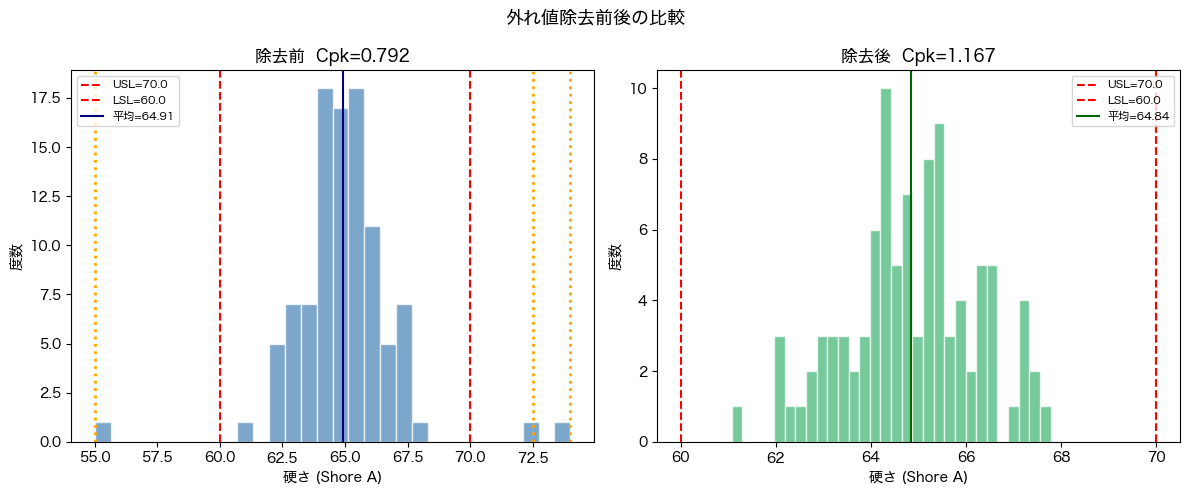

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 共通設定
bins = 30

# 左：除去前
axes[0].hist(hardness, bins=bins, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(USL, color='red',   linestyle='--', linewidth=1.5, label=f'USL={USL}')
axes[0].axvline(LSL, color='red',   linestyle='--', linewidth=1.5, label=f'LSL={LSL}')
axes[0].axvline(mean_before, color='navy', linestyle='-', linewidth=1.5, label=f'平均={mean_before:.2f}')
for v in outliers_z:
    axes[0].axvline(v, color='orange', linestyle=':', linewidth=2)
axes[0].set_title(f'除去前  Cpk={cpk_before:.3f}')
axes[0].set_xlabel('硬さ (Shore A)')
axes[0].set_ylabel('度数')
axes[0].legend(fontsize=8)

# 右：除去後
axes[1].hist(hardness_clean, bins=bins, color='mediumseagreen', alpha=0.7, edgecolor='white')
axes[1].axvline(USL, color='red',   linestyle='--', linewidth=1.5, label=f'USL={USL}')
axes[1].axvline(LSL, color='red',   linestyle='--', linewidth=1.5, label=f'LSL={LSL}')
axes[1].axvline(mean_after, color='darkgreen', linestyle='-', linewidth=1.5, label=f'平均={mean_after:.2f}')
axes[1].set_title(f'除去後  Cpk={cpk_after:.3f}')
axes[1].set_xlabel('硬さ (Shore A)')
axes[1].set_ylabel('度数')
axes[1].legend(fontsize=8)

plt.suptitle('外れ値除去前後の比較', fontsize=13)
plt.tight_layout()
plt.show()